# Manual Kalman SOH Features for Prediction

This notebook re-implements the SOH Kalman filter in a notebook-friendly way and turns its outputs into forecasting features.

Goals:

- smooth event-level SOH spikes with a transparent local-trend Kalman model
- expose causal filter outputs that can be used in a predictive model
- compare a raw-feature baseline against a Kalman-enriched predictive model

The filter here is intentionally implemented directly in NumPy rather than calling the existing `state_space.py` wrapper, so the mechanics are visible and editable in the notebook.


## Setup

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


def resolve_timeseries_path(repo_root: Path) -> Path:
    preferred = repo_root / "data" / "event_timeseries_corrected.parquet"
    fallback = repo_root / "data" / "event_timeseries.parquet"
    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not find local event_timeseries parquet")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.latent_soh.condition_noise import compute_condition_scores, estimate_measurement_variance, resolve_rt_profile
from ml_workspace.latent_soh.event_observation_dataset import load_aux_rows, build_event_observation_table
from ml_workspace.latent_soh.spec_loader import load_plane_battery_spec

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

PLANE_ID = "166"
RT_PROFILE = "balanced"
Q_LEVEL_DAY_SIGMA_PCT = 0.06
Q_SLOPE_DAY_SIGMA_PCT = 0.01
TRAIN_FRAC = 0.70
VALID_FRAC = 0.15

TIMESERIES_PATH = resolve_timeseries_path(REPO_ROOT)
SPEC_PATH = REPO_ROOT / "ml_workspace" / "battery_specs.yaml"
OUTPUT_DIR = REPO_ROOT / "ml_workspace" / "soh_estimation" / "output" / f"manual_kalman_plane_{PLANE_ID}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Timeseries:", TIMESERIES_PATH)
print("Output dir:", OUTPUT_DIR)


Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane
Timeseries: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/data/event_timeseries_corrected.parquet
Output dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_estimation/output/manual_kalman_plane_166


## Load event observations and build condition-aware measurement noise

In [10]:
spec = load_plane_battery_spec(SPEC_PATH, PLANE_ID)
raw_aux = load_aux_rows(TIMESERIES_PATH, plane_id=PLANE_ID)
event_df = build_event_observation_table(raw_aux, spec=spec)
event_df = event_df[event_df["observed_soh_pct"].notna()].copy()
event_df = compute_condition_scores(event_df, spec=spec)
event_df = estimate_measurement_variance(event_df, rt_profile=resolve_rt_profile(RT_PROFILE))
event_df = event_df.sort_values(["battery_id", "event_datetime", "flight_id"]).reset_index(drop=True)

print("Event rows:", len(event_df))
display(
    event_df.groupby("battery_id", as_index=False).agg(
        n_events=("flight_id", "count"),
        observed_soh_min=("observed_soh_pct", "min"),
        observed_soh_max=("observed_soh_pct", "max"),
        sigma_median=("measurement_sigma_pct", "median"),
        condition_multiplier_median=("condition_multiplier", "median"),
    ).round(3)
)
display(event_df.head(10))


Event rows: 1106


,battery_id,n_events,observed_soh_min,observed_soh_max,sigma_median,condition_multiplier_median
0,1,553,40.0,100.0,1.452,2.640
1,2,553,42.0,100.0,1.430,2.599


,plane_id,battery_id,flight_id,event_datetime,event_type,observed_soh_pct,observed_soh_iqr_pct,observed_soh_span_pct,flag_new_est_batt_cap_any,flag_rst_coulomb_any,n_rows,event_duration_s,avg_cell_temp_mean_c,avg_cell_temp_min_c,avg_cell_temp_max_c,avg_cell_temp_span_c,current_abs_mean_a,p95_abs_current_a,current_span_a,voltage_mean_v,voltage_max_v,soc_mean_pct,soc_min_pct,soc_max_pct,soc_span_pct,kalman_coulomb_gap_mean_pct,kalman_coulomb_gap_span_pct,cap_est_delta_raw,cap_est_span_raw,p95_abs_dtemp_c_per_min,p95_abs_dcurrent_a_per_s,score_current,score_didt,score_dtemp,score_soc_edge,score_observation_instability,score_gap,score_switch,score_event_type,score_missing,sigma_base_pct,rt_profile,condition_multiplier,measurement_sigma_pct_raw,measurement_sigma_pct,measurement_var_pct2
0,166,1,4575,2023-05-16 11:00:00,charge,100.0,0.0,0.0,0,1,15745,3148.773794,19.366211,18.0,21.0,3.0,7.928485,23.9,24.7,399.971204,404.0,92.914004,77.0,100.0,23.0,-0.160428,2.55,0.0,0.0,0.0,0.500425,0.597500,0.133272,0.0,1.0,0.0,1.307086,0.5,0.75,0.0,0.55,balanced,2.344184,1.289301,1.289301,1.662298
1,166,1,4576,2023-05-16 12:44:00,other,100.0,0.0,0.0,0,1,9638,1927.385601,21.981531,0.0,25.0,25.0,39.186315,54.1,70.2,362.911289,401.9,68.764889,29.0,100.0,71.0,-0.875459,1.76,9611.0,9611.0,0.0,6.453240,0.450833,0.659758,0.0,1.0,0.0,1.055092,0.5,0.25,0.0,0.55,balanced,2.305847,1.268216,1.268216,1.608372
2,166,1,4577,2023-05-16 13:00:00,charge,97.0,3.0,3.0,1,1,18774,3754.583319,24.594759,0.0,25.0,25.0,19.859817,27.8,28.7,384.956695,403.9,70.749867,29.0,100.0,71.0,-1.070712,0.85,9519.0,9611.0,0.0,0.500641,0.695000,0.133319,0.0,1.0,3.0,0.639142,1.5,0.75,0.0,0.55,balanced,5.192570,2.855914,2.855914,8.156243
3,166,1,4578,2023-05-16 14:35:00,other,97.0,0.0,0.0,0,1,11409,2281.582631,23.502586,23.0,25.0,2.0,31.840792,37.3,70.4,365.043676,400.5,66.621439,29.0,100.0,71.0,-0.238266,1.09,0.0,0.0,0.0,5.486243,0.310833,0.614114,0.0,1.0,0.0,0.592653,0.5,0.25,0.0,0.55,balanced,2.078858,1.143372,1.143372,1.307300
4,166,1,4579,2023-05-16 15:00:00,charge,96.0,1.0,1.0,1,1,20922,4184.178628,25.281665,24.0,26.0,2.0,17.670701,27.6,28.7,388.008159,404.5,74.653475,29.0,100.0,71.0,-0.422913,0.30,-16.0,16.0,0.0,0.500691,0.690000,0.133330,0.0,1.0,1.0,0.234583,1.5,0.75,0.0,0.55,balanced,3.468707,1.907789,1.907789,3.639658
5,166,1,4580,2023-05-16 19:11:00,other,96.0,0.0,0.0,0,1,11247,2249.382045,26.689695,25.0,29.0,4.0,33.295874,45.5,71.1,368.054023,401.6,69.464391,27.0,100.0,73.0,0.010462,0.85,0.0,0.0,0.0,6.008600,0.379167,0.639554,0.0,1.0,0.0,0.427092,0.5,0.25,0.0,0.55,balanced,2.073533,1.140443,1.140443,1.300610
6,166,1,4581,2023-05-16 20:00:00,charge,97.0,1.0,1.0,1,1,19540,3907.768970,26.808137,24.0,29.0,5.0,19.093480,27.9,29.1,386.424447,403.9,72.170573,27.0,100.0,73.0,0.338948,0.96,25.0,25.0,0.0,0.500749,0.697500,0.133342,0.0,1.0,1.0,0.547790,1.5,0.75,0.0,0.55,balanced,3.566424,1.961533,1.961533,3.847612
7,166,1,4582,2023-05-16 21:19:00,other,97.0,0.0,97.0,0,1,13917,2783.582473,23.509018,23.0,24.0,1.0,26.285119,40.5,71.2,367.196695,401.8,66.701229,29.0,100.0,71.0,0.050900,0.80,0.0,0.0,0.0,3.993421,0.337500,0.528201,0.0,1.0,0.0,0.410180,0.5,0.25,0.0,0.55,balanced,2.003085,1.101697,1.101697,1.213735
8,166,1,4583,2023-05-16 22:00:00,charge,97.0,0.0,97.0,1,1,5727,1145.193014,23.261568,0.0,24.0,24.0,19.641592,27.8,28.9,359.950428,372.7,37.243583,29.0,51.0,22.0,-0.660726,0.42,9528.0,9528.0,0.0,0.500472,0.695000,0.133282,0.0,0.0,0.0,0.342145,1.5,0.75,0.0,0.55,balanced,2.553456,1.404401,1.404401,1.972342
9,166,1,4584,2023-05-17 11:30:00,charge,96.0,1.0,1.0,0,0,17948,3589.369774,19.024571,18.0,21.0,3.0,14.088366,24.6,25.4,395.197175,403.9,83.548808,51.0,100.0,49.0,-0.812017,1.85,-28.0,28.0,0.0,0.500365,0.615000,0.133259,0.0,1.0,1.0,1.087403,0.0,0.75,0.0,0.55,balanced,2.787024,1.532863,1.532863,2.349670


## Manual local-trend Kalman filter

State:

- `level_t`: latent SOH level
- `slope_t`: latent SOH drift per day

Transition:

- `level_t = level_{t-1} + slope_{t-1} * dt + noise`
- `slope_t = slope_{t-1} + noise`

Observation:

- `observed_soh_t = level_t + measurement_noise`

The measurement noise is time-varying and comes from the same condition-aware logic already used in `latent_soh`.


In [11]:
def prepare_sequence(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values(["event_datetime", "flight_id"]).reset_index(drop=True).copy()
    g["delta_days"] = g["event_datetime"].diff().dt.total_seconds().div(86400.0).clip(lower=1e-4, upper=30.0)
    g.loc[g.index[0], "delta_days"] = 1e-4
    return g


def initial_state(observed_soh: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    finite = observed_soh[np.isfinite(observed_soh)]
    level0 = float(np.median(finite[: min(5, len(finite))]))
    slope0 = float(np.median(np.diff(finite[: min(8, len(finite))])) if len(finite) >= 3 else 0.0)
    x0 = np.array([level0, slope0], dtype=float)
    p0 = np.diag([4.0, 0.25]).astype(float)
    return x0, p0


def run_manual_local_trend_filter(group: pd.DataFrame, q_level_day_sigma_pct: float, q_slope_day_sigma_pct: float) -> pd.DataFrame:
    g = prepare_sequence(group)
    z = g["observed_soh_pct"].to_numpy(dtype=float)
    r = g["measurement_var_pct2"].to_numpy(dtype=float)
    dt = g["delta_days"].to_numpy(dtype=float)
    n = len(g)

    x_filt = np.zeros((n, 2), dtype=float)
    p_filt = np.zeros((n, 2, 2), dtype=float)
    x_pred = np.zeros((n, 2), dtype=float)
    p_pred = np.zeros((n, 2, 2), dtype=float)
    innovations = np.zeros(n, dtype=float)
    innovation_var = np.zeros(n, dtype=float)
    kalman_gain_level = np.zeros(n, dtype=float)
    kalman_gain_slope = np.zeros(n, dtype=float)
    transition_mats = []

    x_prev, p_prev = initial_state(z)
    for t in range(n):
        F = np.array([[1.0, dt[t]], [0.0, 1.0]], dtype=float)
        Q = np.diag(
            [
                (q_level_day_sigma_pct ** 2) * dt[t],
                (q_slope_day_sigma_pct ** 2) * dt[t],
            ]
        ).astype(float)
        H = np.array([[1.0, 0.0]], dtype=float)

        x_prior = F @ x_prev
        p_prior = F @ p_prev @ F.T + Q

        y = float(z[t] - (H @ x_prior)[0])
        S = float((H @ p_prior @ H.T)[0, 0] + r[t])
        K = (p_prior @ H.T) / S
        x_post = x_prior + (K[:, 0] * y)
        p_post = (np.eye(2) - K @ H) @ p_prior

        x_pred[t] = x_prior
        p_pred[t] = p_prior
        x_filt[t] = x_post
        p_filt[t] = p_post
        innovations[t] = y
        innovation_var[t] = S
        kalman_gain_level[t] = K[0, 0]
        kalman_gain_slope[t] = K[1, 0]
        transition_mats.append(F)

        x_prev, p_prev = x_post, p_post

    x_smooth = x_filt.copy()
    p_smooth = p_filt.copy()
    for t in range(n - 2, -1, -1):
        F_next = transition_mats[t + 1]
        C = p_filt[t] @ F_next.T @ np.linalg.pinv(p_pred[t + 1])
        x_smooth[t] = x_filt[t] + C @ (x_smooth[t + 1] - x_pred[t + 1])
        p_smooth[t] = p_filt[t] + C @ (p_smooth[t + 1] - p_pred[t + 1]) @ C.T

    g["kf_level_pred_pct"] = x_pred[:, 0]
    g["kf_slope_pred_pct_per_day"] = x_pred[:, 1]
    g["kf_level_filter_pct"] = x_filt[:, 0]
    g["kf_slope_filter_pct_per_day"] = x_filt[:, 1]
    g["kf_level_smooth_pct"] = x_smooth[:, 0]
    g["kf_slope_smooth_pct_per_day"] = x_smooth[:, 1]
    g["kf_pred_std_pct"] = np.sqrt(np.clip(p_pred[:, 0, 0], 0.0, None))
    g["kf_level_std_pct"] = np.sqrt(np.clip(p_filt[:, 0, 0], 0.0, None))
    g["kf_slope_std_pct_per_day"] = np.sqrt(np.clip(p_filt[:, 1, 1], 0.0, None))
    g["kf_smooth_std_pct"] = np.sqrt(np.clip(p_smooth[:, 0, 0], 0.0, None))
    g["kf_innovation_pct"] = innovations
    g["kf_innovation_std_pct"] = np.sqrt(np.clip(innovation_var, 1e-12, None))
    g["kf_innovation_z"] = g["kf_innovation_pct"] / g["kf_innovation_std_pct"]
    g["kf_kalman_gain_level"] = kalman_gain_level
    g["kf_kalman_gain_slope"] = kalman_gain_slope
    g["kf_residual_filter_pct"] = g["observed_soh_pct"] - g["kf_level_filter_pct"]
    g["kf_residual_smooth_pct"] = g["observed_soh_pct"] - g["kf_level_smooth_pct"]
    return g


latent_frames = []
for _, group in event_df.groupby(["plane_id", "battery_id"], sort=False, observed=True):
    latent_frames.append(
        run_manual_local_trend_filter(
            group,
            q_level_day_sigma_pct=Q_LEVEL_DAY_SIGMA_PCT,
            q_slope_day_sigma_pct=Q_SLOPE_DAY_SIGMA_PCT,
        )
    )
manual_kf_df = pd.concat(latent_frames, ignore_index=True)
manual_kf_df = manual_kf_df.sort_values(["battery_id", "event_datetime", "flight_id"]).reset_index(drop=True)

display(
    manual_kf_df[
        [
            "battery_id",
            "event_datetime",
            "observed_soh_pct",
            "kf_level_filter_pct",
            "kf_level_smooth_pct",
            "kf_slope_filter_pct_per_day",
            "kf_innovation_pct",
            "measurement_sigma_pct",
        ]
    ].head(12).round(3)
)


,battery_id,event_datetime,observed_soh_pct,kf_level_filter_pct,kf_level_smooth_pct,kf_slope_filter_pct_per_day,kf_innovation_pct,measurement_sigma_pct
0,1,2023-05-16 11:00:00,100.0,99.119,96.930,0.000,3.000,1.289
1,1,2023-05-16 12:44:00,100.0,99.491,96.929,0.006,0.881,1.268
2,1,2023-05-16 13:00:00,97.0,99.300,96.929,0.002,-2.491,2.856
3,1,2023-05-16 14:35:00,97.0,98.552,96.927,-0.032,-2.300,1.143
4,1,2023-05-16 15:00:00,96.0,98.284,96.927,-0.047,-2.551,1.908
5,1,2023-05-16 19:11:00,96.0,97.744,96.923,-0.134,-2.276,1.140
6,1,2023-05-16 20:00:00,97.0,97.684,96.922,-0.144,-0.739,1.962
7,1,2023-05-16 21:19:00,97.0,97.545,96.921,-0.174,-0.676,1.102
8,1,2023-05-16 22:00:00,97.0,97.482,96.921,-0.189,-0.540,1.404
9,1,2023-05-17 11:30:00,96.0,97.196,96.910,-0.286,-1.376,1.533


## Smoothing diagnostics

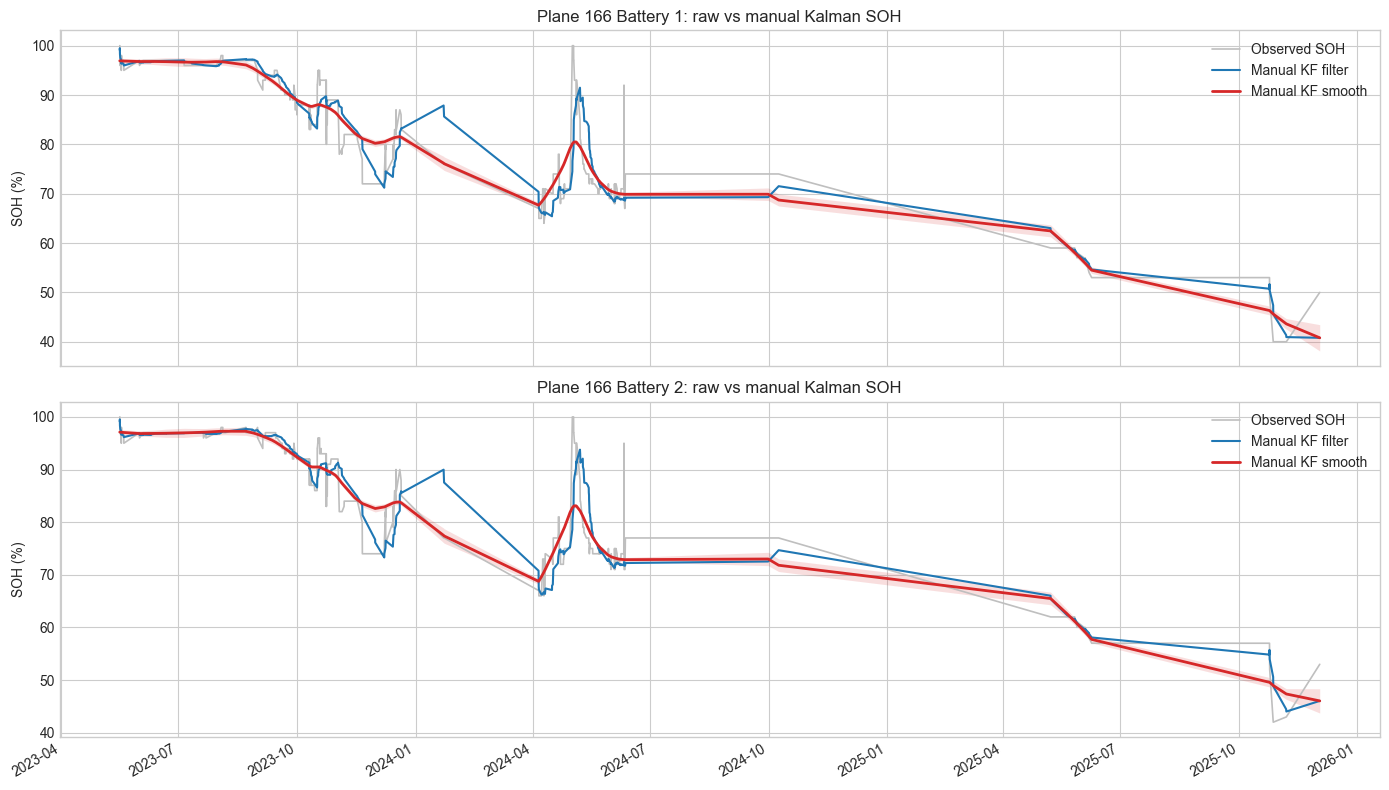

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, (battery_id, group) in zip(axes, manual_kf_df.groupby("battery_id", sort=True)):
    g = group.sort_values(["event_datetime", "flight_id"])
    ax.plot(g["event_datetime"], g["observed_soh_pct"], color="0.75", linewidth=1.2, label="Observed SOH")
    ax.plot(g["event_datetime"], g["kf_level_filter_pct"], color="#1f77b4", linewidth=1.5, label="Manual KF filter")
    ax.plot(g["event_datetime"], g["kf_level_smooth_pct"], color="#d62728", linewidth=2.0, label="Manual KF smooth")
    ax.fill_between(
        g["event_datetime"],
        g["kf_level_smooth_pct"] - 2.0 * g["kf_smooth_std_pct"],
        g["kf_level_smooth_pct"] + 2.0 * g["kf_smooth_std_pct"],
        color="#d62728",
        alpha=0.15,
        linewidth=0,
    )
    ax.set_title(f"Plane {PLANE_ID} Battery {battery_id}: raw vs manual Kalman SOH")
    ax.set_ylabel("SOH (%)")
    ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()


In [13]:
spike_rows = []
for battery_id, group in manual_kf_df.groupby("battery_id", sort=True):
    g = group.sort_values(["event_datetime", "flight_id"]).copy()
    raw_delta = g["observed_soh_pct"].diff()
    filt_delta = g["kf_level_filter_pct"].diff()
    smooth_delta = g["kf_level_smooth_pct"].diff()
    spike_rows.append(
        {
            "battery_id": battery_id,
            "raw_max_upward_jump_pct": raw_delta.max(),
            "filter_max_upward_jump_pct": filt_delta.max(),
            "smooth_max_upward_jump_pct": smooth_delta.max(),
            "raw_total_variation": raw_delta.abs().sum(),
            "filter_total_variation": filt_delta.abs().sum(),
            "smooth_total_variation": smooth_delta.abs().sum(),
        }
    )
spike_compare = pd.DataFrame(spike_rows)
display(spike_compare.round(3))


,battery_id,raw_max_upward_jump_pct,filter_max_upward_jump_pct,smooth_max_upward_jump_pct,raw_total_variation,filter_total_variation,smooth_total_variation
0,1,29.0,4.680,2.748,484.0,190.976,85.505
1,2,25.0,4.402,2.693,469.0,190.586,83.482


## Build a predictive dataset

Key design choice:

- use **causal filter outputs** as features
- use the **next smoothed SOH** as the target label

That gives a cleaner forecasting target while avoiding future leakage in the input features.


In [14]:
model_df = manual_kf_df.sort_values(["battery_id", "event_datetime", "flight_id"]).copy()
model_df["next_kf_level_smooth_pct"] = model_df.groupby(["plane_id", "battery_id"], sort=False)["kf_level_smooth_pct"].shift(-1)
model_df["next_observed_soh_pct"] = model_df.groupby(["plane_id", "battery_id"], sort=False)["observed_soh_pct"].shift(-1)
model_df["next_delta_latent_pct"] = model_df["next_kf_level_smooth_pct"] - model_df["kf_level_filter_pct"]
model_df["next_delta_observed_pct"] = model_df["next_observed_soh_pct"] - model_df["observed_soh_pct"]
model_df["next_gap_days"] = model_df.groupby(["plane_id", "battery_id"], sort=False)["delta_days"].shift(-1)

predictive_df = model_df[model_df["next_kf_level_smooth_pct"].notna()].copy()
predictive_df["battery_id_str"] = predictive_df["battery_id"].astype(str)

raw_feature_cols = [
    "observed_soh_pct",
    "current_abs_mean_a",
    "p95_abs_current_a",
    "avg_cell_temp_mean_c",
    "avg_cell_temp_span_c",
    "soc_mean_pct",
    "soc_span_pct",
    "event_duration_s",
    "measurement_sigma_pct",
    "condition_multiplier",
]
kalman_feature_cols = [
    "kf_level_filter_pct",
    "kf_slope_filter_pct_per_day",
    "kf_pred_std_pct",
    "kf_level_std_pct",
    "kf_slope_std_pct_per_day",
    "kf_innovation_pct",
    "kf_innovation_z",
    "kf_kalman_gain_level",
    "kf_kalman_gain_slope",
]

display(
    predictive_df[
        [
            "battery_id",
            "event_datetime",
            "observed_soh_pct",
            "kf_level_filter_pct",
            "kf_slope_filter_pct_per_day",
            "kf_innovation_pct",
            "next_kf_level_smooth_pct",
            "next_delta_latent_pct",
        ]
    ].head(12).round(3)
)


,battery_id,event_datetime,observed_soh_pct,kf_level_filter_pct,kf_slope_filter_pct_per_day,kf_innovation_pct,next_kf_level_smooth_pct,next_delta_latent_pct
0,1,2023-05-16 11:00:00,100.0,99.119,0.000,3.000,96.929,-2.190
1,1,2023-05-16 12:44:00,100.0,99.491,0.006,0.881,96.929,-2.563
2,1,2023-05-16 13:00:00,97.0,99.300,0.002,-2.491,96.927,-2.372
3,1,2023-05-16 14:35:00,97.0,98.552,-0.032,-2.300,96.927,-1.625
4,1,2023-05-16 15:00:00,96.0,98.284,-0.047,-2.551,96.923,-1.361
5,1,2023-05-16 19:11:00,96.0,97.744,-0.134,-2.276,96.922,-0.821
6,1,2023-05-16 20:00:00,97.0,97.684,-0.144,-0.739,96.921,-0.763
7,1,2023-05-16 21:19:00,97.0,97.545,-0.174,-0.676,96.921,-0.624
8,1,2023-05-16 22:00:00,97.0,97.482,-0.189,-0.540,96.910,-0.572
9,1,2023-05-17 11:30:00,96.0,97.196,-0.286,-1.376,96.908,-0.288


## Train/test split and utilities

In [15]:
def time_split(df: pd.DataFrame, train_frac: float, valid_frac: float) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    work = df.sort_values("event_datetime").reset_index(drop=True)
    n = len(work)
    n_train = max(1, int(round(n * train_frac)))
    n_valid = max(1, int(round(n * valid_frac))) if n >= 3 else max(0, n - n_train)
    if n_train + n_valid >= n:
        n_valid = max(1, n - n_train - 1) if n >= 3 else max(0, n - n_train)
    train = work.iloc[:n_train].copy()
    valid = work.iloc[n_train : n_train + n_valid].copy()
    test = work.iloc[n_train + n_valid :].copy()
    return train, valid, test


def make_feature_frame(df: pd.DataFrame, numeric_cols: list[str], include_kalman: bool) -> pd.DataFrame:
    cols = raw_feature_cols + (kalman_feature_cols if include_kalman else [])
    cols = [c for c in cols if c in df.columns]
    numeric = df[cols].apply(pd.to_numeric, errors="coerce").copy()
    numeric = numeric.fillna(numeric.median()).fillna(0.0)
    battery_dummies = pd.get_dummies(df["battery_id_str"], prefix="battery")
    event_dummies = pd.get_dummies(df["event_type"].fillna("unknown"), prefix="event_type")
    return pd.concat([numeric.reset_index(drop=True), battery_dummies.reset_index(drop=True), event_dummies.reset_index(drop=True)], axis=1)


def metric_table(y_true_level: np.ndarray, y_pred_level: np.ndarray, y_true_delta: np.ndarray, y_pred_delta: np.ndarray) -> dict[str, float]:
    return {
        "level_mae": float(mean_absolute_error(y_true_level, y_pred_level)),
        "level_rmse": float(np.sqrt(mean_squared_error(y_true_level, y_pred_level))),
        "level_r2": float(r2_score(y_true_level, y_pred_level)),
        "delta_mae": float(mean_absolute_error(y_true_delta, y_pred_delta)),
        "delta_rmse": float(np.sqrt(mean_squared_error(y_true_delta, y_pred_delta))),
        "delta_r2": float(r2_score(y_true_delta, y_pred_delta)),
    }


train_df, valid_df, test_df = time_split(predictive_df, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC)
print("Train / valid / test:", len(train_df), len(valid_df), len(test_df))


Train / valid / test: 773 166 165


## Compare prediction models

We train three next-step predictors:

- naive: next latent delta = 0
- raw-only ridge: event features without Kalman states
- Kalman-enriched ridge: raw event features plus causal Kalman outputs

A fourth model, Kalman-enriched gradient boosting, is included as a nonlinear check.


In [16]:
y_train = train_df["next_delta_latent_pct"].to_numpy(dtype=float)
y_valid = valid_df["next_delta_latent_pct"].to_numpy(dtype=float)
y_test = test_df["next_delta_latent_pct"].to_numpy(dtype=float)

current_level_train = train_df["kf_level_filter_pct"].to_numpy(dtype=float)
current_level_valid = valid_df["kf_level_filter_pct"].to_numpy(dtype=float)
current_level_test = test_df["kf_level_filter_pct"].to_numpy(dtype=float)

X_train_raw = make_feature_frame(train_df, raw_feature_cols, include_kalman=False)
X_valid_raw = make_feature_frame(valid_df, raw_feature_cols, include_kalman=False)
X_test_raw = make_feature_frame(test_df, raw_feature_cols, include_kalman=False)
X_valid_raw = X_valid_raw.reindex(columns=X_train_raw.columns, fill_value=0.0)
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0.0)

X_train_kf = make_feature_frame(train_df, raw_feature_cols + kalman_feature_cols, include_kalman=True)
X_valid_kf = make_feature_frame(valid_df, raw_feature_cols + kalman_feature_cols, include_kalman=True)
X_test_kf = make_feature_frame(test_df, raw_feature_cols + kalman_feature_cols, include_kalman=True)
X_valid_kf = X_valid_kf.reindex(columns=X_train_kf.columns, fill_value=0.0)
X_test_kf = X_test_kf.reindex(columns=X_train_kf.columns, fill_value=0.0)

scaler_raw = StandardScaler()
scaler_kf = StandardScaler()
X_train_raw_s = scaler_raw.fit_transform(X_train_raw)
X_valid_raw_s = scaler_raw.transform(X_valid_raw)
X_test_raw_s = scaler_raw.transform(X_test_raw)
X_train_kf_s = scaler_kf.fit_transform(X_train_kf)
X_valid_kf_s = scaler_kf.transform(X_valid_kf)
X_test_kf_s = scaler_kf.transform(X_test_kf)

candidate_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

def fit_best_ridge(X_train, y_train, X_valid, y_valid):
    best = None
    best_mae = float("inf")
    for alpha in candidate_alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        mae = mean_absolute_error(y_valid, pred)
        if mae < best_mae:
            best = model
            best_mae = mae
    return best


naive_pred_delta = np.zeros_like(y_test)
naive_pred_level = current_level_test + naive_pred_delta

raw_ridge = fit_best_ridge(X_train_raw_s, y_train, X_valid_raw_s, y_valid)
raw_pred_delta = raw_ridge.predict(X_test_raw_s)
raw_pred_level = current_level_test + raw_pred_delta

kf_ridge = fit_best_ridge(X_train_kf_s, y_train, X_valid_kf_s, y_valid)
kf_ridge_pred_delta = kf_ridge.predict(X_test_kf_s)
kf_ridge_pred_level = current_level_test + kf_ridge_pred_delta

kf_gbdt = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=3,
    max_iter=300,
    min_samples_leaf=10,
    random_state=42,
)
kf_gbdt.fit(X_train_kf, y_train)
kf_gbdt_pred_delta = kf_gbdt.predict(X_test_kf)
kf_gbdt_pred_level = current_level_test + kf_gbdt_pred_delta

test_target_level = test_df["next_kf_level_smooth_pct"].to_numpy(dtype=float)

metrics = pd.DataFrame(
    [
        {"model": "naive_zero_delta", **metric_table(test_target_level, naive_pred_level, y_test, naive_pred_delta)},
        {"model": "ridge_raw_only", **metric_table(test_target_level, raw_pred_level, y_test, raw_pred_delta)},
        {"model": "ridge_kalman_enriched", **metric_table(test_target_level, kf_ridge_pred_level, y_test, kf_ridge_pred_delta)},
        {"model": "gbdt_kalman_enriched", **metric_table(test_target_level, kf_gbdt_pred_level, y_test, kf_gbdt_pred_delta)},
    ]
)
display(metrics.round(4))


,model,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,1.4390,2.1938,0.9456,1.4390,2.1938,-0.0084
1,ridge_raw_only,2.1985,3.1047,0.8910,2.1985,3.1047,-1.0197
2,ridge_kalman_enriched,4.6215,5.6718,0.6362,4.6215,5.6718,-5.7405
3,gbdt_kalman_enriched,3.7406,4.7703,0.7426,3.7406,4.7703,-3.7680


## Prediction plots

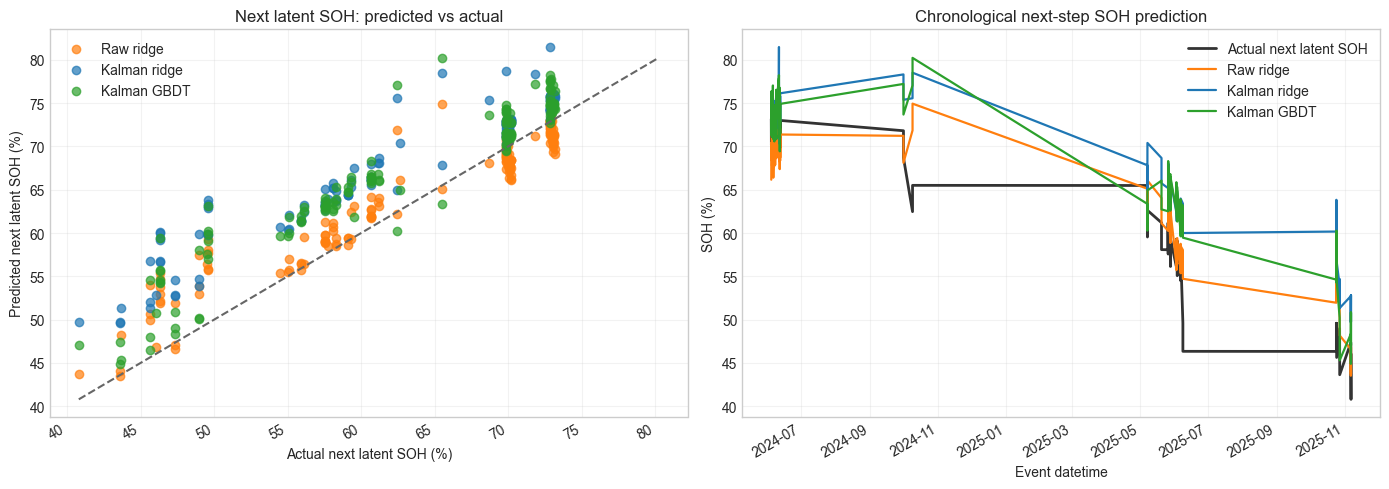

In [17]:
plot_df = test_df[["battery_id", "event_datetime", "kf_level_filter_pct", "next_kf_level_smooth_pct", "next_observed_soh_pct"]].copy()
plot_df["pred_next_level_raw_ridge"] = raw_pred_level
plot_df["pred_next_level_kf_ridge"] = kf_ridge_pred_level
plot_df["pred_next_level_kf_gbdt"] = kf_gbdt_pred_level
plot_df["pred_next_delta_raw_ridge"] = raw_pred_delta
plot_df["pred_next_delta_kf_ridge"] = kf_ridge_pred_delta
plot_df["pred_next_delta_kf_gbdt"] = kf_gbdt_pred_delta

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(plot_df["next_kf_level_smooth_pct"], plot_df["pred_next_level_raw_ridge"], alpha=0.7, label="Raw ridge", color="#ff7f0e")
axes[0].scatter(plot_df["next_kf_level_smooth_pct"], plot_df["pred_next_level_kf_ridge"], alpha=0.7, label="Kalman ridge", color="#1f77b4")
axes[0].scatter(plot_df["next_kf_level_smooth_pct"], plot_df["pred_next_level_kf_gbdt"], alpha=0.7, label="Kalman GBDT", color="#2ca02c")
lo = min(plot_df["next_kf_level_smooth_pct"].min(), plot_df["pred_next_level_kf_gbdt"].min())
hi = max(plot_df["next_kf_level_smooth_pct"].max(), plot_df["pred_next_level_kf_gbdt"].max())
axes[0].plot([lo, hi], [lo, hi], linestyle="--", color="0.4")
axes[0].set_title("Next latent SOH: predicted vs actual")
axes[0].set_xlabel("Actual next latent SOH (%)")
axes[0].set_ylabel("Predicted next latent SOH (%)")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.25)

plot_df = plot_df.sort_values("event_datetime")
axes[1].plot(plot_df["event_datetime"], plot_df["next_kf_level_smooth_pct"], color="0.2", linewidth=2, label="Actual next latent SOH")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_raw_ridge"], color="#ff7f0e", linewidth=1.6, label="Raw ridge")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_kf_ridge"], color="#1f77b4", linewidth=1.6, label="Kalman ridge")
axes[1].plot(plot_df["event_datetime"], plot_df["pred_next_level_kf_gbdt"], color="#2ca02c", linewidth=1.6, label="Kalman GBDT")
axes[1].set_title("Chronological next-step SOH prediction")
axes[1].set_xlabel("Event datetime")
axes[1].set_ylabel("SOH (%)")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()


## Which Kalman features matter?

In [18]:
coef_df = pd.DataFrame(
    {
        "feature": X_train_kf.columns,
        "coef": kf_ridge.coef_,
        "abs_coef": np.abs(kf_ridge.coef_),
    }
).sort_values("abs_coef", ascending=False)
display(coef_df.head(20).round(4))


,feature,coef,abs_coef
11,kf_slope_filter_pct_per_day,-1.9093,1.9093
15,kf_innovation_pct,1.3177,1.3177
10,kf_level_filter_pct,-1.0305,1.0305
16,kf_innovation_z,0.5972,0.5972
0,observed_soh_pct,-0.4183,0.4183
13,kf_level_std_pct,0.4000,0.4000
7,event_duration_s,-0.3240,0.3240
2,p95_abs_current_a,0.3005,0.3005
3,avg_cell_temp_mean_c,-0.2474,0.2474
6,soc_span_pct,0.1919,0.1919


## Save outputs

In [19]:
manual_kf_df.to_csv(OUTPUT_DIR / "manual_kalman_event_table.csv", index=False)
predictive_df.to_csv(OUTPUT_DIR / "manual_kalman_predictive_dataset.csv", index=False)
plot_df.to_csv(OUTPUT_DIR / "manual_kalman_test_predictions.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "manual_kalman_prediction_metrics.csv", index=False)
coef_df.to_csv(OUTPUT_DIR / "manual_kalman_ridge_coefficients.csv", index=False)

print("Saved outputs to", OUTPUT_DIR)


Saved outputs to /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_estimation/output/manual_kalman_plane_166


## Interpretation

In [20]:
display(metrics.round(4))
best_row = metrics.sort_values("level_mae").iloc[0]
print(f"Best model by next-level MAE: {best_row['model']}")
print("- If a Kalman-enriched model beats the raw-only ridge, the filter is adding useful state information rather than only smoothing plots.")
print("- The most useful Kalman features are usually latent level, latent slope, innovation size, and uncertainty.")
print("- For downstream forecasting, use filter outputs as features and keep smoother outputs only as denoised training labels.")


,model,level_mae,level_rmse,level_r2,delta_mae,delta_rmse,delta_r2
0,naive_zero_delta,1.4390,2.1938,0.9456,1.4390,2.1938,-0.0084
1,ridge_raw_only,2.1985,3.1047,0.8910,2.1985,3.1047,-1.0197
2,ridge_kalman_enriched,4.6215,5.6718,0.6362,4.6215,5.6718,-5.7405
3,gbdt_kalman_enriched,3.7406,4.7703,0.7426,3.7406,4.7703,-3.7680


Best model by next-level MAE: naive_zero_delta
- If a Kalman-enriched model beats the raw-only ridge, the filter is adding useful state information rather than only smoothing plots.
- The most useful Kalman features are usually latent level, latent slope, innovation size, and uncertainty.
- For downstream forecasting, use filter outputs as features and keep smoother outputs only as denoised training labels.
